# **Drug Design with Machine Learning — CYP1A2 Activity Prediction**

This notebook uses **DrugKit** with **Monte Carlo Dropout Prediction** to train a Graph Neural Network (GINE) and identify potential new molecules active against **CYP1A2** (Cytochrome P450 1A2).

**Workflow:**
1. Load and preprocess CYP1A2 bioactivity data
2. Convert SMILES to molecular graphs using DrugKit featurization
3. Train a GINE classifier with Monte Carlo Dropout
4. Evaluate model with uncertainty quantification
5. Screen a compound pool to find potential CYP1A2-active molecules

## 1. Setup and Imports

Install required packages and import DrugKit modules.

In [1]:
!pip install meeko
!pip install gemmi
!pip install rdkit
!pip install biopython
!pip install chembl_webresource_client

# DrugKit
!pip install -i https://test.pypi.org/simple/ drugkit==0.1.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.1 MB/s eta 0:00:00
Looking in indexes: https://test.pypi.org/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.4/156.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.9 MB/s eta 0:00:00


In [2]:
import os
import sys
import random
import logging

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_add_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    precision_score, recall_score, classification_report
)

from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from chembl_webresource_client.new_client import new_client

# DrugKit modules
from siamese_GNN.featurization import (
    smiles_to_graph_gine, get_atom_features, get_bond_features, feature_dims
)
from siamese_GNN.model import GINEEncoder, enable_mc_dropout
from active_learning.uncertainty import mc_dropout_predict


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)


PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


## 2. Load CYP1A2 Bioactivity Data from Database

CYP1A2 is an important drug-metabolizing enzyme. We fetch the dataset directly from an online repository — no local files needed.

In [4]:
# Download CYP1A2 dataset directly from online repository
url = 'https://raw.githubusercontent.com/kugi8412/DockGraph/CYP1A2/SelectGINE/CYP1A2/data/cyp1a2.tab'
df = pd.read_csv(url, sep='\t')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nLabel distribution:')
print(df['Y'].value_counts())
print(f'\nSample entries:')
df.head()


Dataset shape: (12579, 3)
Columns: ['Drug_ID', 'Drug', 'Y']

Label distribution:
Y
0    6750
1    5829
Name: count, dtype: int64

Sample entries:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Drug_ID,Drug,Y
0,6602638.0,CCCC(=O)Nc1ccc(N2CCN(CC)CC2)c(Cl)c1.Cl,0
1,644510.0,O=c1[nH]c2cc3c(cc2cc1CN(CCCO)Cc1nnnn1Cc1ccc(F)...,1
2,1960010.0,CCN1C(=O)/C(=C2\SC(=S)N(CCCOC)C2=O)c2ccccc21,1
3,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,1
4,644851.0,Clc1ccccc1-c1nc(-c2ccccc2)n[nH]1,1


## 3. Molecular Graph Featurization (DrugKit)

We use DrugKit's `smiles_to_graph_gine` to convert each SMILES string into a PyTorch Geometric graph object with:
- **Node features** (atom-level): element type, degree, H-count, charge, hybridization, aromaticity, mass, chirality
- **Edge features** (bond-level): bond type, conjugation, ring membership, stereochemistry

In [5]:
# Convert SMILES to molecular graphs using DrugKit featurization
graphs = []
failed = 0

for idx, row in df.iterrows():
    g = smiles_to_graph_gine(row['Drug'], selectivity=float(row['Y']))
    if g is not None:
        graphs.append(g)
    else:
        failed += 1

# Get feature dimensions from DrugKit
node_dim, edge_dim = feature_dims()

print(f'Successfully converted: {len(graphs)} molecules')
print(f'Failed conversions: {failed}')
print(f'Node feature dimension: {node_dim}')
print(f'Edge feature dimension: {edge_dim}')
print(f'\nExample graph: {graphs[0]}')


Successfully converted: 12579 molecules
Failed conversions: 0
Node feature dimension: 42
Edge feature dimension: 11

Example graph: Data(x=[22, 42], edge_index=[2, 44], edge_attr=[44, 11], y=[1], is_elite=[1], smiles='CCCC(=O)Nc1ccc(N2CCN(CC)CC2)c(Cl)c1.Cl')


In [6]:
aspirin_smiles = "CC(=O)Oc1ccccc1C(=O)O"
aspirin_graph = smiles_to_graph_gine(aspirin_smiles, selectivity=0.0, is_elite=False)

print(f"Molecule: Aspirin")
print(f"Number of Atoms: {aspirin_graph.x.shape[0]}")
print(f"Number of Bonds: {aspirin_graph.edge_attr.shape[0]}")

print("\n<-- Node Features (Atom 0) -->")
print(f"Shape: {aspirin_graph.x[0].shape}")
print(f"Values:\n{aspirin_graph.x[0]}")

print("\n<-- Edge Features (Bond 0) -->")
print(f"Shape: {aspirin_graph.edge_attr[0].shape}")
print(f"Values:\n{aspirin_graph.edge_attr[0]}")


Molecule: Aspirin
Number of Atoms: 13
Number of Bonds: 26

<-- Node Features (Atom 0) -->
Shape: torch.Size([42])
Values:
tensor([1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.1201, 0.0000, 0.0000, 1.0000])

<-- Edge Features (Bond 0) -->
Shape: torch.Size([11])
Values:
tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


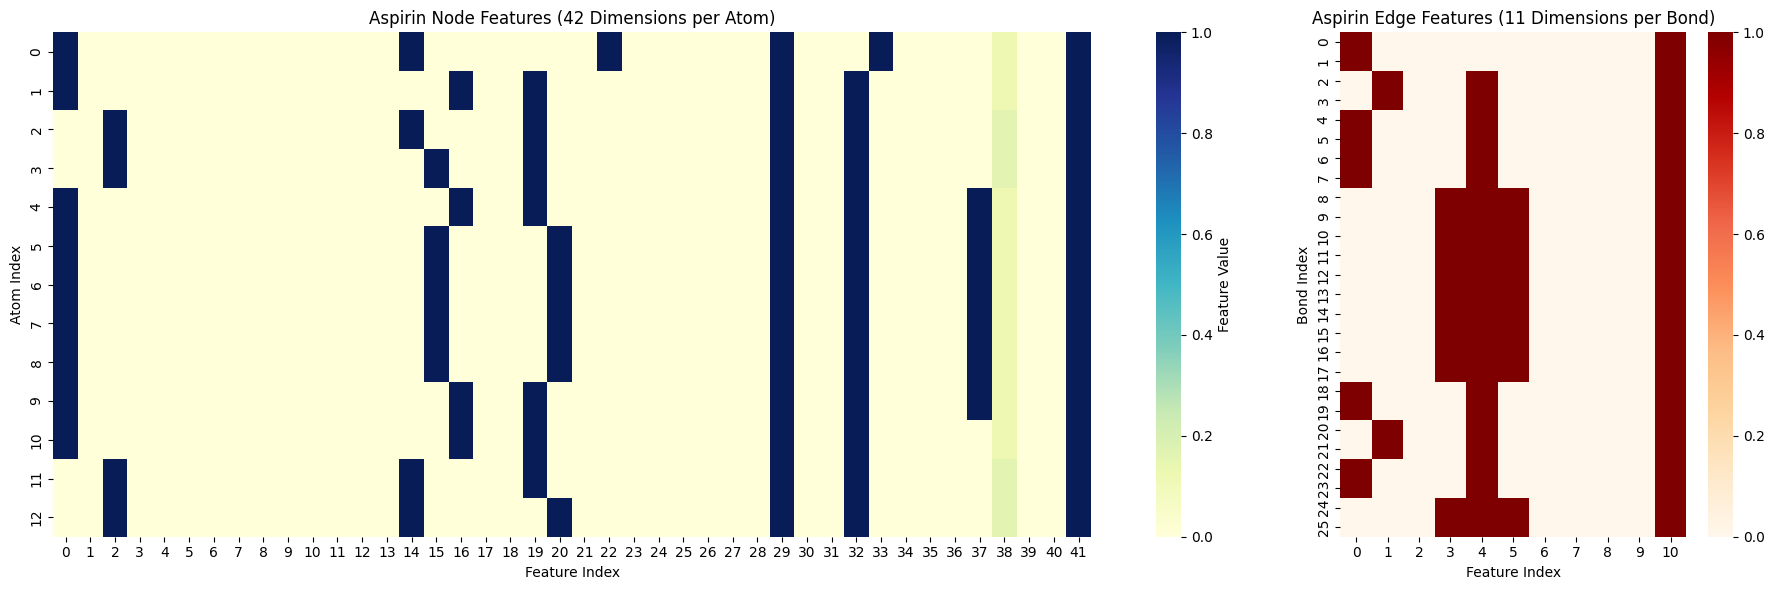

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
def plot_molecular_features(graph, title_prefix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [3, 1]})

    # Plot Node Features
    sns.heatmap(graph.x.numpy(), annot=False, cmap="YlGnBu", ax=ax1, cbar_kws={'label': 'Feature Value'})
    ax1.set_title(f"{title_prefix} Node Features (42 Dimensions per Atom)")
    ax1.set_xlabel("Feature Index")
    ax1.set_ylabel("Atom Index")

    # Plot Edge Features
    sns.heatmap(graph.edge_attr.numpy(), annot=False, cmap="OrRd", ax=ax2)
    ax2.set_title(f"{title_prefix} Edge Features (11 Dimensions per Bond)")
    ax2.set_xlabel("Feature Index")
    ax2.set_ylabel("Bond Index")

    plt.tight_layout()
    plt.show()


plot_molecular_features(aspirin_graph, title_prefix="Aspirin")


## 4. Train/Validation/Test Split

In [8]:
# Configuration
CONFIG = {
    'batch_size': 64,
    'epochs': 60,
    'learning_rate': 0.0005,
    'hidden_dim': 128,
    'dropout': 0.3,
    'mc_samples': 30,     # Monte Carlo dropout forward passes
    'seed': SEED,
    'val_split': 0.15,
    'test_split': 0.15
}

# Shuffle and split
random.shuffle(graphs)
total = len(graphs)
n_val = int(total * CONFIG['val_split'])
n_test = int(total * CONFIG['test_split'])
n_train = total - n_val - n_test

train_data = graphs[:n_train]
val_data = graphs[n_train:n_train + n_val]
test_data = graphs[n_train + n_val:]

train_loader = DataLoader(train_data, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_data, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_data, batch_size=CONFIG['batch_size'], shuffle=False)

print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')


Train: 8807 | Val: 1886 | Test: 1886


## 5. GINE Classifier with Monte Carlo Dropout

We build a GINE (Graph Isomorphism Network with Edge features) classifier using DrugKit's `GINEEncoder` backbone. The key innovation is using **nn.Dropout modules** (not functional dropout) so we can enable stochastic forward passes at inference time for Monte Carlo prediction.

### Monte Carlo Dropout
Instead of a single deterministic prediction, we run multiple stochastic forward passes with dropout active. This gives us:
- **Mean prediction**: robust estimate of activity
- **Standard deviation**: uncertainty quantification (molecules with high uncertainty are candidates for further experimental validation)

In [9]:
class MCDropoutGINEClassifier(nn.Module):
    """GINE classifier with Monte Carlo Dropout for uncertainty estimation.

    Uses DrugKit's GINEEncoder backbone with nn.Dropout modules
    that remain active during MC inference (via enable_mc_dropout).
    """
    def __init__(self, node_in, edge_in, hidden_dim, dropout=0.3):
        super().__init__()
        self.encoder = GINEEncoder(node_in, edge_in, hidden_dim, dropout)
        self.head_drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward_one(self, data):
        """Single forward pass (compatible with DrugKit MC dropout API)."""
        x = self.encoder(data.x, data.edge_index, data.edge_attr, data.batch)
        x = self.head_drop(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

    def forward(self, data):
        return self.forward_one(data)


model = MCDropoutGINEClassifier(
    node_dim, edge_dim, CONFIG['hidden_dim'], CONFIG['dropout']
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')


MCDropoutGINEClassifier(
  (encoder): GINEEncoder(
    (node_lin): Linear(in_features=42, out_features=128, bias=True)
    (edge_lin): Linear(in_features=11, out_features=128, bias=True)
    (conv1): GINEConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
    ))
    (conv2): GINEConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
    ))
    (conv3): GINEConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out

## 6. Training Loop

We train with Binary Cross-Entropy loss (from logits) and Adam optimizer with learning rate scheduling.

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-5
)

train_losses, val_losses = [], []
val_aucs = []

print('Training GINE Classifier with MC Dropout...')
print('=' * 70)

for epoch in range(CONFIG['epochs']):
    # Training
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y.unsqueeze(1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    scheduler.step()

    # Validation
    model.eval()
    val_loss = 0
    y_true, y_probs = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y.unsqueeze(1))
            val_loss += loss.item()
            probs = torch.sigmoid(out).cpu().numpy()
            y_probs.extend(probs.flatten())
            y_true.extend(batch.y.cpu().numpy().flatten())

    avg_val_loss = val_loss / len(val_loader)
    try:
        val_auc = roc_auc_score(y_true, y_probs)
    except ValueError:
        val_auc = 0.0

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_aucs.append(val_auc)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:02d}/{CONFIG["epochs"]} | '
              f'Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | '
              f'Val AUC: {val_auc:.4f}')

print('=' * 70)
print(f'Best Val AUC: {max(val_aucs):.4f} (Epoch {np.argmax(val_aucs)+1})')


Training GINE Classifier with MC Dropout...
Epoch 10/60 | Train Loss: 0.4026 | Val Loss: 0.5317 | Val AUC: 0.8860


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 20/60 | Train Loss: 0.3632 | Val Loss: 0.4067 | Val AUC: 0.9072


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 30/60 | Train Loss: 0.3284 | Val Loss: 0.3903 | Val AUC: 0.9173


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 50/60 | Train Loss: 0.2778 | Val Loss: 0.3986 | Val AUC: 0.9189


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 60/60 | Train Loss: 0.2693 | Val Loss: 0.3973 | Val AUC: 0.9208
Best Val AUC: 0.9214 (Epoch 52)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 7. Training Curves

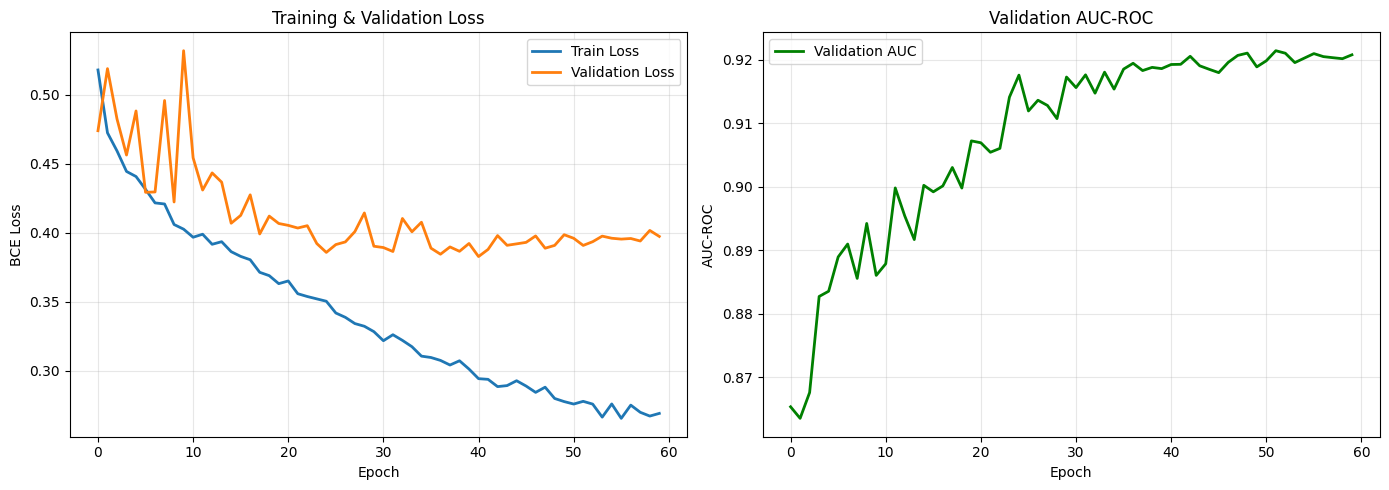

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_aucs, label='Validation AUC', color='green', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC-ROC')
ax2.set_title('Validation AUC-ROC')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Monte Carlo Dropout Evaluation on Test Set

Instead of a single forward pass, we run **multiple stochastic passes** with dropout active. This gives us uncertainty estimates for each prediction.

Using DrugKit's `enable_mc_dropout()` — keeps BatchNorm in eval mode (using running statistics) while Dropout layers remain stochastic.

In [12]:
# Monte Carlo Dropout Prediction
mc_samples = CONFIG['mc_samples']
print(f'Running {mc_samples} MC Dropout forward passes on test set...')

# Use DrugKit's enable_mc_dropout to set correct mode
enable_mc_dropout(model)

mc_predictions = np.zeros((mc_samples, len(test_data)))

with torch.no_grad():
    for t in range(mc_samples):
        loader = DataLoader(test_data, batch_size=CONFIG['batch_size'], shuffle=False)
        offset = 0
        for batch in loader:
            batch = batch.to(device)
            out = torch.sigmoid(model(batch)).cpu().numpy().flatten()
            mc_predictions[t, offset:offset + len(out)] = out
            offset += len(out)

# Aggregate MC predictions
mc_mean = mc_predictions.mean(axis=0)    # Mean probability
mc_std = mc_predictions.std(axis=0)       # Uncertainty (std)

# Binary predictions from MC mean
mc_preds = (mc_mean > 0.5).astype(float)

# Ground truth
test_true = np.array([g.y.item() for g in test_data])

print(f'\nMC Dropout Results:')
print(f'  Mean uncertainty (std): {mc_std.mean():.4f}')
print(f'  Max uncertainty: {mc_std.max():.4f}')
print(f'  Min uncertainty: {mc_std.min():.4f}')

Running 30 MC Dropout forward passes on test set...

MC Dropout Results:
  Mean uncertainty (std): 0.0741
  Max uncertainty: 0.3135
  Min uncertainty: 0.0000


## 9. Test Set Metrics

In [13]:
# Classification metrics
test_acc = accuracy_score(test_true, mc_preds)
test_auc = roc_auc_score(test_true, mc_mean)
test_precision = precision_score(test_true, mc_preds)
test_recall = recall_score(test_true, mc_preds)
cm = confusion_matrix(test_true, mc_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print('=' * 50)
print('  TEST SET RESULTS (Monte Carlo Dropout)')
print('=' * 50)
print(f'  Accuracy:    {test_acc:.4f}')
print(f'  AUC-ROC:     {test_auc:.4f}')
print(f'  Precision:   {test_precision:.4f}')
print(f'  Recall:      {test_recall:.4f}')
print(f'  Specificity: {specificity:.4f}')
print(f'\n  TP: {tp} | FP: {fp} | TN: {tn} | FN: {fn}')
print('=' * 50)


  TEST SET RESULTS (Monte Carlo Dropout)
  Accuracy:    0.8600
  AUC-ROC:     0.9320
  Precision:   0.8722
  Recall:      0.8362
  Specificity: 0.8828

  TP: 771 | FP: 113 | TN: 851 | FN: 151


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


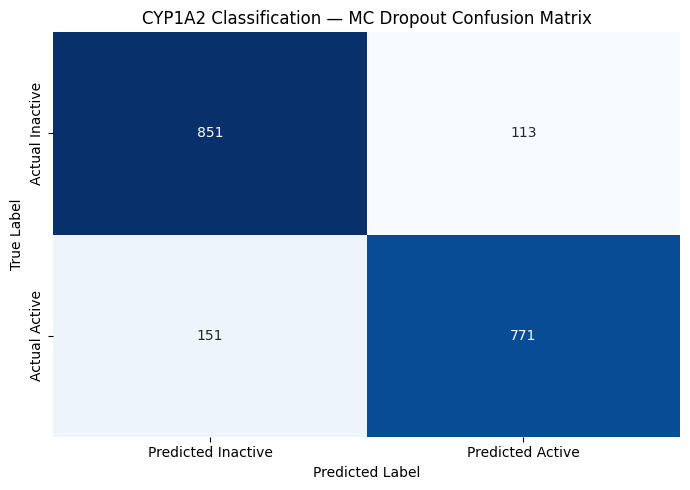

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
# Confusion Matrix visualization
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Inactive', 'Predicted Active'],
            yticklabels=['Actual Inactive', 'Actual Active'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CYP1A2 Classification — MC Dropout Confusion Matrix')
plt.tight_layout()
plt.show()


## 10. Uncertainty Analysis

Molecules with **high uncertainty** are the most informative for active learning. They sit near the decision boundary and would benefit most from experimental validation.

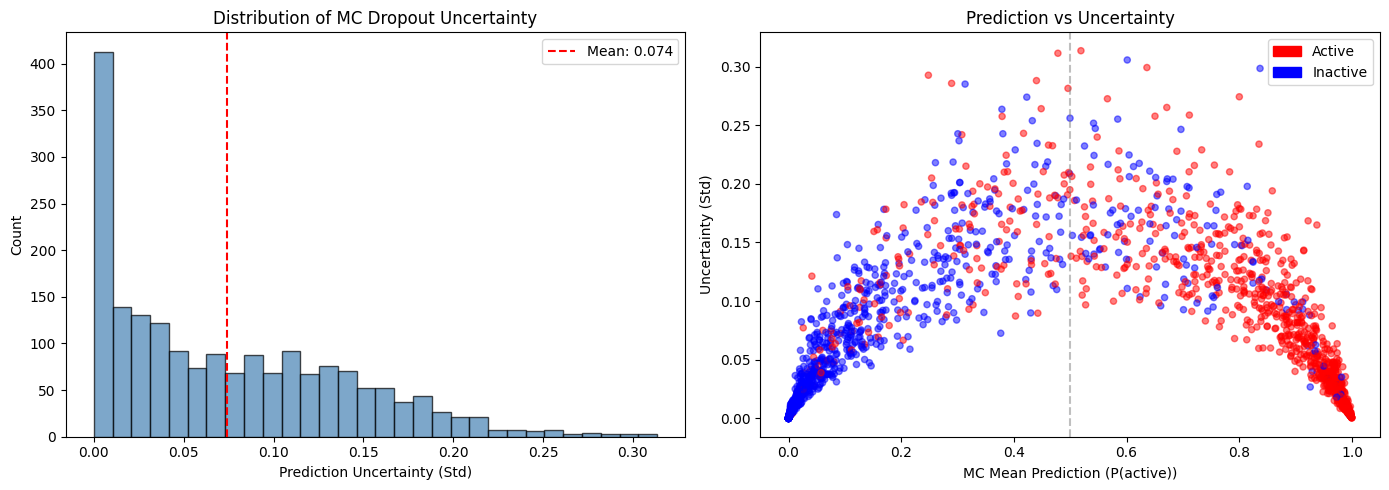

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of uncertainties
ax1.hist(mc_std, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Prediction Uncertainty (Std)')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of MC Dropout Uncertainty')
ax1.axvline(mc_std.mean(), color='red', linestyle='--', label=f'Mean: {mc_std.mean():.3f}')
ax1.legend()

# Uncertainty vs Prediction
colors = ['red' if t == 1 else 'blue' for t in test_true]
ax2.scatter(mc_mean, mc_std, c=colors, alpha=0.5, s=20)
ax2.set_xlabel('MC Mean Prediction (P(active))')
ax2.set_ylabel('Uncertainty (Std)')
ax2.set_title('Prediction vs Uncertainty')
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5)

# Legend
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='red', label='Active'), Patch(color='blue', label='Inactive')])

plt.tight_layout()
plt.show()


## 11. Virtual Screening — Find New CYP1A2-Active Molecules

We query the **ChEMBL database** to fetch a pool of drug-like compounds for screening. Using the ChEMBL web API, we retrieve molecules with reported activity on CYP-family targets that haven't been tested on CYP1A2 specifically. These are our screening candidates.

In [16]:
# Search for compounds with activity on CYP targets (potential cross-reactivity candidates)
molecule = new_client.molecule

# Fetch drug-like molecules from ChEMBL
results = molecule.filter(
    molecule_properties__mw_freebase__lte=500,
    molecule_properties__mw_freebase__gte=150,
    molecule_properties__alogp__lte=5,
    molecule_properties__hbd__lte=5,
    molecule_properties__hba__lte=10,
).only(['molecule_chembl_id', 'pref_name', 'molecule_structures'])[:500]

# Extract SMILES from ChEMBL results
pool_data = []
for mol in results:
    if mol.get('molecule_structures') and mol['molecule_structures'].get('canonical_smiles'):
        smi = mol['molecule_structures']['canonical_smiles']
        name = mol.get('pref_name') or mol.get('molecule_chembl_id', 'Unknown')
        pool_data.append({'Name': name, 'SMILES': smi})

pool_df = pd.DataFrame(pool_data).drop_duplicates(subset='SMILES').reset_index(drop=True)

# Remove molecules already in training set
train_smiles_set = set(df['Drug'].tolist())
pool_df = pool_df[~pool_df['SMILES'].isin(train_smiles_set)].reset_index(drop=True)

print(f'Screening pool size: {len(pool_df)} compounds from ChEMBL')
pool_df.head()


Screening pool size: 493 compounds from ChEMBL


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Name,SMILES
0,CHEMBL6329,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl
1,CHEMBL6328,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1
2,CHEMBL265667,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1
3,CHEMBL6362,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1
4,CHEMBL267864,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1


In [17]:
# Featurize the screening pool
pool_graphs = []
pool_smiles = []
pool_names = []

for idx, row in pool_df.iterrows():
    smi = row['SMILES']
    g = smiles_to_graph_gine(smi)
    if g is not None:
        pool_graphs.append(g)
        pool_smiles.append(smi)
        pool_names.append(row.get('Name', f'Compound_{idx}'))

print(f'Valid molecules for screening: {len(pool_graphs)}')


Valid molecules for screening: 493


In [18]:
# MC Dropout prediction on the screening pool
print(f'Running MC Dropout screening ({CONFIG["mc_samples"]} samples).')

enable_mc_dropout(model)

pool_mc = np.zeros((CONFIG['mc_samples'], len(pool_graphs)))

with torch.no_grad():
    for t in range(CONFIG['mc_samples']):
        loader = DataLoader(pool_graphs, batch_size=CONFIG['batch_size'], shuffle=False)
        offset = 0
        for batch in loader:
            batch = batch.to(device)
            out = torch.sigmoid(model(batch)).cpu().numpy().flatten()
            pool_mc[t, offset:offset + len(out)] = out
            offset += len(out)

pool_mean = pool_mc.mean(axis=0)
pool_std = pool_mc.std(axis=0)


Running MC Dropout screening (30 samples).


In [19]:
# Build results DataFrame
results_df = pd.DataFrame({
    'Name': pool_names,
    'SMILES': pool_smiles,
    'P(CYP1A2_Active)': pool_mean,
    'Uncertainty': pool_std,
    'Predicted_Active': (pool_mean > 0.5).astype(int)
})

# Sort by predicted activity (high confidence actives first)
# Confidence score: high probability + low uncertainty
results_df['Confidence_Score'] = results_df['P(CYP1A2_Active)'] - results_df['Uncertainty']
results_df = results_df.sort_values('Confidence_Score', ascending=False)

print(f'\nPredicted CYP1A2-Active Molecules: {results_df["Predicted_Active"].sum()} / {len(results_df)}')
print(f'\n{"=" * 70}')
print('  TOP CANDIDATES — Potential CYP1A2-Active Molecules')
print(f'{"=" * 70}')
print(results_df[results_df['Predicted_Active'] == 1][[
    'Name', 'SMILES', 'P(CYP1A2_Active)', 'Uncertainty', 'Confidence_Score'
]].head(20).to_string(index=False))


Predicted CYP1A2-Active Molecules: 245 / 493

  TOP CANDIDATES — Potential CYP1A2-Active Molecules
        Name                                                  SMILES  P(CYP1A2_Active)  Uncertainty  Confidence_Score
CHEMBL268691                          COc1cc(Br)c2c3c([nH]c2c1)CNCC3          0.998229     0.001678          0.996552
CHEMBL428999                             Brc1ccc2c3c([nH]c2c1)C=NCC3          0.997651     0.002206          0.995445
  CHEMBL6345                      O=C1c2cc(O)c(O)cc2-c2cc(O)c(O)cc21          0.997349     0.002076          0.995273
  CHEMBL6591                             COc1cccc2[nH]c3c(c12)CCN=C3          0.997168     0.002593          0.994575
  CHEMBL6470                              COc1ccc2c(c1)[nH]c1cnccc12          0.996585     0.002035          0.994550
  CHEMBL6586                              COc1cccc2[nH]c3c(c12)CCNC3          0.996438     0.002836          0.993602
  CHEMBL6426                              Brc1cccc2[nH]c3c(c12)CCNC3      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


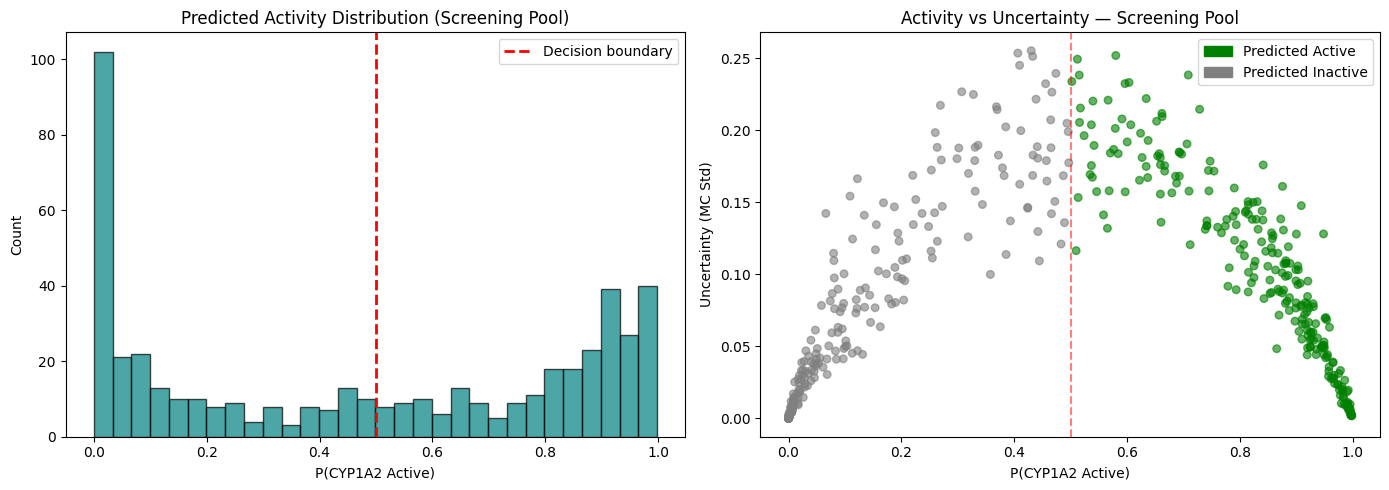

In [20]:
# Visualization of screening results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Activity probability distribution
ax1.hist(pool_mean, bins=30, edgecolor='black', alpha=0.7, color='teal')
ax1.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision boundary')
ax1.set_xlabel('P(CYP1A2 Active)')
ax1.set_ylabel('Count')
ax1.set_title('Predicted Activity Distribution (Screening Pool)')
ax1.legend()

# Confidence plot
colors = ['green' if p > 0.5 else 'gray' for p in pool_mean]
ax2.scatter(pool_mean, pool_std, c=colors, alpha=0.6, s=30)
ax2.set_xlabel('P(CYP1A2 Active)')
ax2.set_ylabel('Uncertainty (MC Std)')
ax2.set_title('Activity vs Uncertainty — Screening Pool')
ax2.axvline(0.5, color='red', linestyle='--', alpha=0.5)
ax2.legend(handles=[
    Patch(color='green', label='Predicted Active'),
    Patch(color='gray', label='Predicted Inactive')
])

plt.tight_layout()
plt.show()


## 12. Export Results

Save the screening results for further analysis or docking validation.

In [21]:
# Save full screening results
output_path = 'cyp1a2_screening_results.csv'
results_df.to_csv(output_path, index=False)
print(f'Results saved to: {output_path}')

# Save top hits
top_hits = results_df[
    (results_df['Predicted_Active'] == 1) &
    (results_df['Uncertainty'] < results_df['Uncertainty'].quantile(0.5))
].copy()

hits_path = 'cyp1a2_top_hits.csv'
top_hits.to_csv(hits_path, index=False)
print(f'Top hits ({len(top_hits)} compounds) saved to: {hits_path}')

print(f'\n<== SUMMARY ==>')
print(f'Total screened: {len(results_df)}')
print(f'Predicted active: {results_df["Predicted_Active"].sum()}')
print(f'High-confidence hits: {len(top_hits)}')


Results saved to: cyp1a2_screening_results.csv
Top hits (97 compounds) saved to: cyp1a2_top_hits.csv

<== SUMMARY ==>
Total screened: 493
Predicted active: 245
High-confidence hits: 97


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Summary

This notebook demonstrated a complete ML drug design workflow using **DrugKit**:

1. **Data**: CYP1A2 bioactivity dataset (binary classification: active/inactive)
2. **Featurization**: DrugKit's `smiles_to_graph_gine` — topology-preserving molecular graphs
3. **Model**: GINE classifier with DrugKit's `GINEEncoder` backbone
4. **Training**: BCE loss with cosine annealing LR schedule
5. **MC Dropout**: Multiple stochastic passes for uncertainty-aware predictions
6. **Screening**: Identified potential CYP1A2-active molecules ranked by confidence

**Next steps:**
- Validate top hits with molecular docking (`drugkit-dock`)
- Run active learning loop (`drugkit-active-learn`) to iteratively improve the model
- Apply selectivity filtering against off-target CYP isoforms